In [13]:
pip install opencv-python

   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/44.0 MB 1.5 MB/s eta 0:00:29
    --------------------------------------- 0.8/44.0 MB 1.3 MB/s eta 0:00:33
    --------------------------------------- 1.0/44.0 MB 1.2 MB/s eta 0:00:35
    --------------------------------------- 1.0/44.0 MB 1.2 MB/s eta 0:00:35
    --------------------------------------- 1.0/44.0 MB 1.2 MB/s eta 0:00:35
    --------------------------------------- 1.0/44.0 MB 1.2 MB/s eta 0:00:35
    --------------------------------------- 1.0/44.0 MB 1.2 MB/s eta 0:00:35
   - -------------------------------------- 1.6/44.0 MB 729.4 kB/s eta 0:00:59
   - -------------------------------------- 1.8/44.0 MB 798.8 kB/s eta 0:00:53
   - ------------------

In [24]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, BatchNormalization, Dropout
import cv2

### Load DataSet

In [17]:
train_path = r"E:\Deep Learning\DL\CNN\train"
test_path = r"E:\Deep Learning\DL\CNN\test"

In [ ]:
train_df = keras.utils.image_dataset_from_directory(
    directory=train_path,
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(256, 256)
)

test_df = keras.utils.image_dataset_from_directory(
    directory=test_path,
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(256, 256)
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


### Data Preprocessing

In [ ]:
# Normalize pixel values from [0, 255] to [0, 1]

def process(image, label):
    image = tf.cast(image / 255., tf.float32)
    return image, label

In [23]:
train_df = train_df.map(process)
test_df = test_df.map(process)

### CNN Model Architecture

In [ ]:
model = Sequential()

# Convaluational Layers

model.add(Conv2D(32, kernel_size=(3, 3), padding='valid', activation='relu', input_shape = (256, 256, 3)))
model.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))
model.add(BatchNormalization())


model.add(Conv2D(64, kernel_size=(3, 3), padding='valid', activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))
model.add(BatchNormalization())


model.add(Conv2D(128, kernel_size=(3, 3), padding='valid', activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))
model.add(BatchNormalization())


model.add(Flatten())


# Fully Connected Layers

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.1))

# Output Layer

model.add(Dense(1, activation='sigmoid'))




# model = Sequential()

# model.add(Conv2D(128, kernel_size=(3, 3), padding='same', activation='relu', input_shape = (256, 256, 3)))
# model.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='same'))
# model.add(BatchNormalization())

# model.add(Conv2D(64, kernel_size=(3, 3), padding='same', activation='relu'))
# model.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='same'))
# model.add(BatchNormalization())

# model.add(Conv2D(32, kernel_size=(3, 3), padding='same', activation='relu'))
# model.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='same'))
# model.add(BatchNormalization())


# model.add(Flatten())

# model.add(Dense(128, activation='relu'))
# model.add(Dropout(0.2))
# model.add(Dense(64, activation='relu'))
# model.add(Dropout(0.1))
# model.add(Dense(32, activation='relu'))
# model.add(Dropout(0.1))

# model.add(Dense(1, activation='sigmoid'))

c:\Users\M Arshad\.conda\envs\deep\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 127, 127, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 62, 62, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 30, 30, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [28]:
history = model.fit(train_df, epochs=10, validation_data=test_df)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1637s 3s/step - accuracy: 0.5720 - loss: 3.4144 - val_accuracy: 0.6802 - val_loss: 0.5839
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3494s 6s/step - accuracy: 0.6968 - loss: 0.5840 - val_accuracy: 0.7312 - val_loss: 0.5339
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1372s 2s/step - accuracy: 0.7514 - loss: 0.5006 - val_accuracy: 0.7536 - val_loss: 0.5003
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1333s 2s/step - accuracy: 0.7909 - loss: 0.4417 - val_accuracy: 0.7258 - val_loss: 0.5918
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1275s 2s/step - accuracy: 0.8264 - loss: 0.3884 - val_accuracy: 0.7728 - val_loss: 0.5325
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1229s 2s/step - accuracy: 0.8575 - loss: 0.3217 - val_accuracy: 0.7890 - val_loss: 0.5628
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1289s 2s/step - accuracy: 0.8933 - loss: 0.2431 - val_accuracy: 0.7696 - val_loss: 0.6386
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1545s 2s/step - accuracy: 0.9198 - loss: 0.1971 - 

### Evaluation (Loss & Accuracy Plots)

### Accuracy

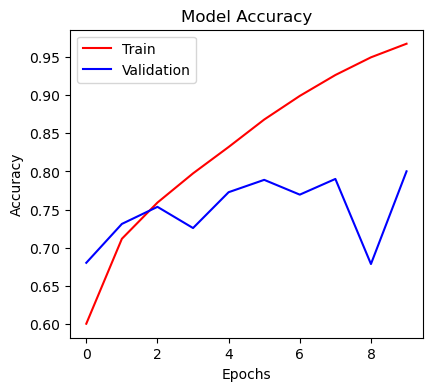

In [30]:
import matplotlib.pyplot as plt
plt.figure(figsize = (10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], color='red', label='Train')
plt.plot(history.history['val_accuracy'], color='blue', label='Validation')
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

### Loss

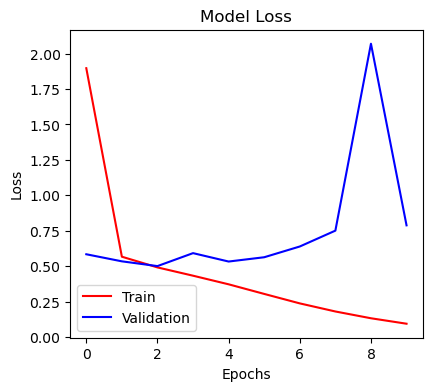

In [31]:
plt.figure(figsize = (10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], color='red', label='Train')
plt.plot(history.history['val_loss'], color='blue', label='Validation')
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

### Prediction New Images

In [55]:
image_path = r'E:\Deep Learning\DL\CNN\dog.jpg'

In [56]:
test_img = cv2.imread('E:\Deep Learning\DL\CNN\dog.jpg')

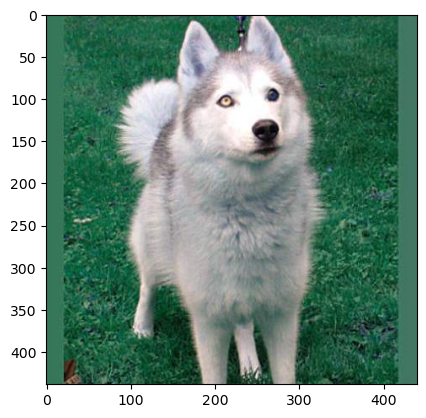

In [57]:
plt.imshow(test_img)

In [58]:
test_img.shape

(439, 440, 3)

In [59]:
test_img = cv2.resize(test_img, (255, 255))

In [60]:
test_input = cv2.resize(test_img, (256, 256)).reshape(1, 256, 256, 3)

In [61]:
model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


array([[0.99999976]], dtype=float32)

In [ ]:
# Replace path with your actual test image path (e.g., 'cat.jpg' or 'dog.jpg')
image_path = 'E:\Deep Learning\DL\CNN\cat.jpg'

if os.path.exists(image_path):
    test_img = cv2.imread(image_path)

    # Convert BGR (OpenCV default) to RGB for correct matplotlib plotting
    test_img_rgb = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
    plt.imshow(test_img_rgb)
    plt.axis('off')
    plt.show()

    # Preprocess the image to fit model expectations
    test_img_resized = cv2.resize(test_img, (256, 256))
    test_input = test_img_resized.reshape((1, 256, 256, 3))

    # Scale image pixels if the training pipeline scales them
    test_input = test_input / 255.0

    # Prediction
    prediction = model.predict(test_input)
    print(f"Raw Prediction Value: {prediction[0][0]}")

    if prediction[0][0] < 0.5:
        print("Prediction: It's a CAT!")
    else:
        print("Prediction: It's a DOG!")
else:
    print(f"Image not found at {E:\Deep Learning\DL\CNN\cat.jpg}. Please check your path.")